<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Operaciones de Aprendizaje Automático III**

# **Clase 2, Parámetros de sampling**

El modelo no devuelve texto: devuelve una distribución de probabilidad sobre todo el vocabulario.
Elegir un token de esa distribución es una decisión nuestra, los parámetros de
sampling son esa decisión.

En este notebook:

* Hacemos una sola pasada del modelo y nos quedamos con el vector de logits.
* Implementamos temperatura, top-k y top-p sobre ese vector.
* Vemos en gráficos qué le hace cada parámetro a la misma distribución.
* Medimos la consecuencia: cuánta variedad real produce cada configuración.
* Mostramos que el orden de aplicación también cambia el resultado.


## **a) Una sola pasada: del prompt a un vector de logits**

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO = "Qwen/Qwen2.5-1.5B-Instruct"
REVISION = "989aa7980e4cf806f80c7fef2b1adb7bc71aa306"   # pinneado

tok = AutoTokenizer.from_pretrained(REPO, revision=REVISION)
modelo = AutoModelForCausalLM.from_pretrained(REPO, revision=REVISION).eval()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Con un prompt muy determinado (`"La capital de Francia es la ciudad de"`) el modelo está tan
seguro que `top_p=0.9` deja **un solo token vivo** y todos los gráficos salen degenerados, usamos uno abierto para que el fenómeno se vea.


In [ ]:
PROMPT = "Ayer fui al mercado y compré"

ids = tok(PROMPT, return_tensors="pt")["input_ids"].to(modelo.device)
with torch.no_grad():
    salida = modelo(ids)

# Nos quedamos solo con la última posición, ahí tenemos la predicción del próximo token
logits = salida.logits[0, -1, :].float().cpu()

print(f"prompt : {PROMPT!r}")
print(f"logits : {logits.numel():,} números (uno por token del vocabulario)")

prompt : 'Ayer fui al mercado y compré'
logits : 151,936 números (uno por token del vocabulario)


## **b) Las tres transformaciones**

Las tres modifican el vector de logits antes del softmax, ninguna toca el modelo

In [ ]:
def temperatura(lg, T):
    """Divide los logits por T, T < 1 agranda las diferencias, T > 1 las aplana.
    T=0 no está definido (división por cero): se interpreta como greedy."""
    return lg if T is None or T <= 0 else lg / T


def top_k(lg, k):
    """Deja los k logits más altos, al resto le pone -inf,
    que después del softmax es probabilidad 0."""
    if not k or k <= 0 or k >= lg.numel():
        return lg
    out = torch.full_like(lg, -float("inf"))
    idx = torch.topk(lg, k).indices
    out[idx] = lg[idx]
    return out


def top_p(lg, p):
    """Deja el conjunto mínimo cuya probabilidad acumulada alcanza p."""
    if p is None or p >= 1.0:
        return lg
    orden = torch.argsort(lg, descending=True)
    pr = torch.softmax(lg[orden], dim=-1)
    acum = torch.cumsum(pr, dim=-1)
    out = lg.clone()
    out[orden[(acum - pr) > p]] = -float("inf")   # el primero siempre sobrevive
    return out


probs = lambda lg: torch.softmax(lg, dim=-1)
vivos = lambda lg: int(torch.isfinite(lg).sum())   # cuántos candidatos quedan


def sortear(lg, n=500, seed=42, greedy=False):
    """Sortea n veces el próximo token, con greedy=True
    devuelve siempre el máximo, que es lo que hace do_sample=False."""
    if greedy:
        return torch.full((n,), int(torch.argmax(lg)))
    torch.manual_seed(seed)  # comparable entre configuraciones
    return torch.multinomial(probs(lg), n, replacement=True)

## **c) Estilo de los gráficos**

Dos familias de color,:

* **Rampa azul de claro a oscuro** para la temperatura, porque es una magnitud ordenada.
* **Tres colores distintos** para las configuraciones, porque entre ellas no hay orden.


In [ ]:
AZULES = ["#86b6ef", "#3987e5", "#1c5cab", "#104281"] # secuencial: claro a oscuro
CAT = ["#2a78d6", "#eb6834", "#1baf7a"]  # categórico: azul, naranja, aqua
TINTA, GRIS, GRILLA, FONDO = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"


def nueva_fig(titulo, subtitulo, eje="y"):
    """Figura con grilla y ejes recesivos: lo que se mira son los datos, no el marco."""
    fig, ax = plt.subplots(figsize=(11, 5.2), facecolor=FONDO)
    ax.set_title(f"{titulo}\n{subtitulo}", fontsize=13, color=TINTA, loc="left", pad=14)
    ax.grid(axis=eje, color=GRILLA, lw=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRILLA)
    ax.tick_params(colors=GRIS, length=0, labelsize=10)
    return fig, ax


# Los 12 candidatos más probables: el eje x de varios gráficos.
top12     = torch.topk(probs(logits), 12)
etiquetas = [tok.decode([i]).strip() or "␣" for i in top12.indices.tolist()]

print("Los 12 candidatos más probables para el próximo token:")
for r, (p, i) in enumerate(zip(top12.values.tolist(), top12.indices.tolist()), 1):
    print(f"  {r:>2}. {tok.decode([i])!r:<16} {p:>7.2%}")

Los 12 candidatos más probables para el próximo token:
   1. ' un'             20.04%
   2. ' una'            17.68%
   3. ' '               13.77%
   4. ' algunas'         3.07%
   5. ' tres'            2.71%
   6. ' unas'            2.71%
   7. ' dos'             2.25%
   8. ' algunos'         2.11%
   9. ' algo'            1.98%
  10. ' unos'            1.98%
  11. ' varios'          1.55%
  12. ' a'               1.28%


## **d) Temperatura: la pendiente es el parámetro**

Escala logarítmica en el eje y. Sin ella, a T=0.3 el token favorito aplasta visualmente a todo
lo demás y no se ve nada de lo que pasa en la cola, que es justo lo que cambia.

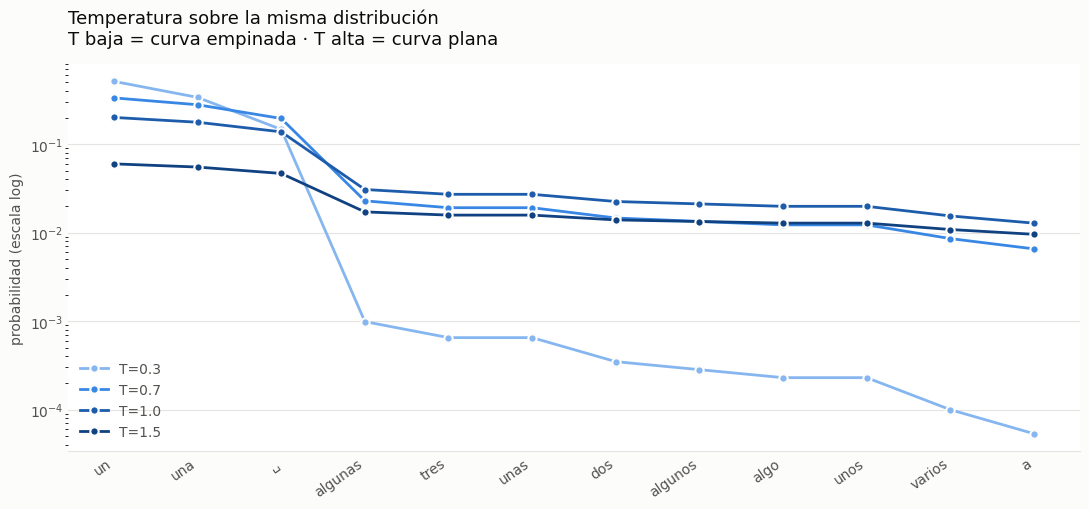

In [ ]:
fig, ax = nueva_fig("Temperatura sobre la misma distribución",
                    "T baja = curva empinada · T alta = curva plana")

for T, color in zip([0.3, 0.7, 1.0, 1.5], AZULES):
    p = probs(temperatura(logits, T))[top12.indices]
    ax.plot(range(12), p, "o-", lw=2, ms=6, color=color, mec=FONDO, mew=1.5, label=f"T={T}")

ax.set_yscale("log")
ax.set_xticks(range(12), etiquetas, rotation=35, ha="right")
ax.set_ylabel("probabilidad (escala log)", color=GRIS, fontsize=10)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS, loc="lower left")
plt.tight_layout(); plt.show()

La temperatura no *mejora* el modelo: **redistribuye el riesgo** entre repetitivo y delirante.
Con T=0.3 la decisión ya está tomada antes de sortear. Con T=1.5 casi cualquier token es posible.

## **e) Top-p: la masa acumulada**

Escala logarítmica en el eje x, porque el corte puede caer en el token 3 o en el 3.000 según
cuán segura esté la distribución

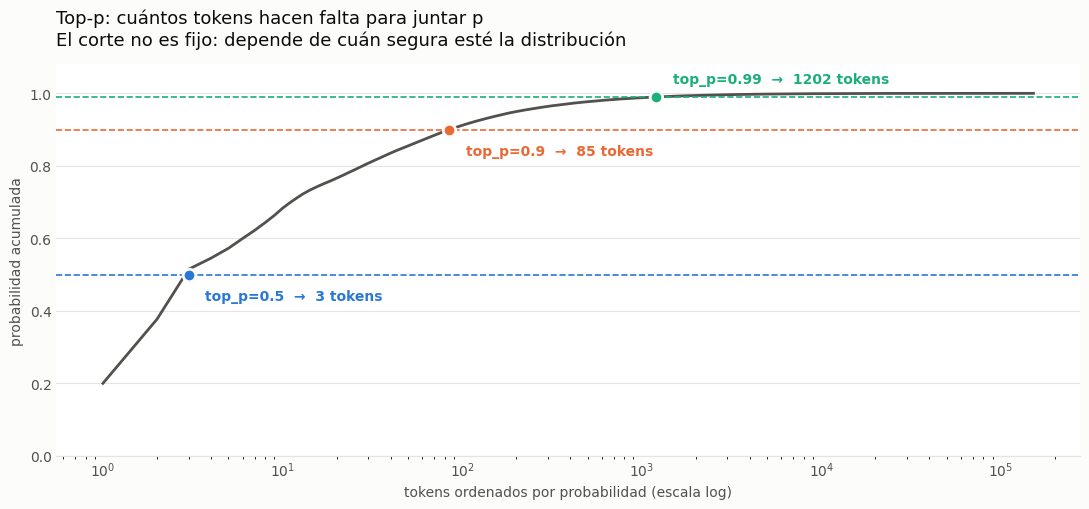

In [ ]:
fig, ax = nueva_fig("Top-p: cuántos tokens hacen falta para juntar p",
                    "El corte no es fijo: depende de cuán segura esté la distribución")

orden = torch.argsort(logits, descending=True)
acum  = torch.cumsum(probs(logits)[orden], dim=-1)
ax.plot(np.arange(1, len(acum) + 1), acum, color=GRIS, lw=2)

for p_, color, dy in zip([0.5, 0.9, 0.99], CAT, [-18, -18, 10]):
    k_ = vivos(top_p(logits, p_))
    ax.axhline(p_, color=color, lw=1.2, ls="--")
    ax.plot([k_], [p_], "o", ms=9, color=color, mec=FONDO, mew=2)

    ax.annotate(f"top_p={p_}  →  {k_} tokens", (k_, p_), xytext=(12, dy),
                textcoords="offset points", color=color, fontsize=10, fontweight="bold")

ax.set_xscale("log")
ax.set_xlabel("tokens ordenados por probabilidad (escala log)", color=GRIS, fontsize=10)
ax.set_ylabel("probabilidad acumulada", color=GRIS, fontsize=10)
ax.set_ylim(0, 1.08)
plt.tight_layout(); plt.show()

## **f) Cuántos candidatos quedan en juego**

`top_k` fija un **número**. `top_p` fija una **masa de probabilidad**, y el número de
sobrevivientes sale de la distribución, no de nosotros.

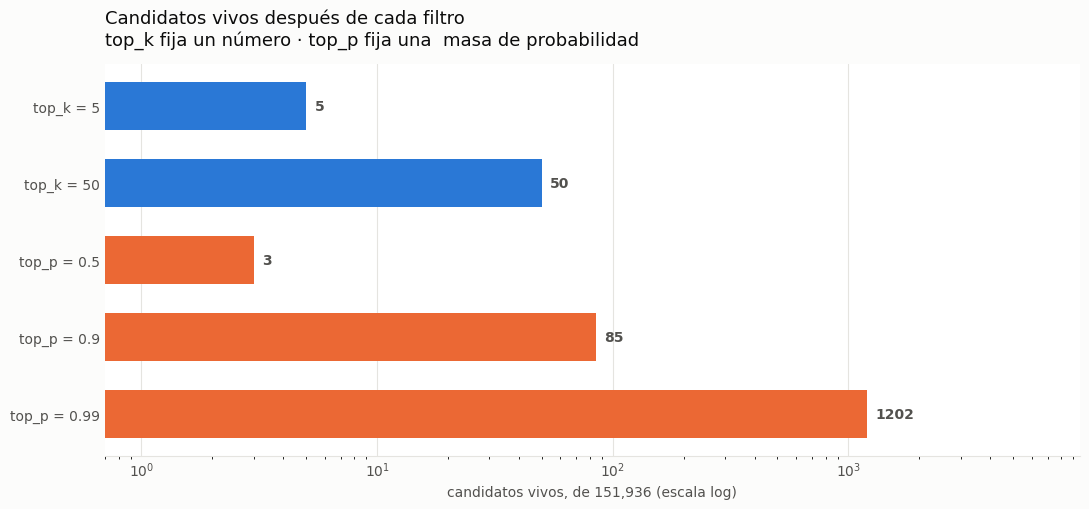

In [ ]:
fig, ax = nueva_fig("Candidatos vivos después de cada filtro",
                    "top_k fija un número · top_p fija una  masa de probabilidad", eje="x")

casos = [("top_k = 5",  top_k(logits, 5)),   ("top_k = 50",   top_k(logits, 50)),
         ("top_p = 0.5",  top_p(logits, .5)),  ("top_p = 0.9",  top_p(logits, .9)),
         ("top_p = 0.99", top_p(logits, .99))]
cuentas = [vivos(c[1]) for c in casos]

# El color separa las dos familias; el número exacto va escrito en cada barra.
barras = ax.barh([c[0] for c in casos], cuentas,
                 color=[CAT[0]] * 2 + [CAT[1]] * 3, height=0.62)
ax.bar_label(barras, padding=6, fontsize=10, color=GRIS, fontweight="bold")

ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlim(0.7, max(cuentas) * 8)
ax.set_xlabel(f"candidatos vivos, de {logits.numel():,} (escala log)", color=GRIS, fontsize=10)
plt.tight_layout(); plt.show()

## **g) La consecuencia: cuánta variedad produce cada configuración**

Los gráficos anteriores muestran la distribución, este muestra lo que ve el usuario:
sorteamos 500 veces el próximo token del **mismo prompt** y contamos cuántos distintos salen.

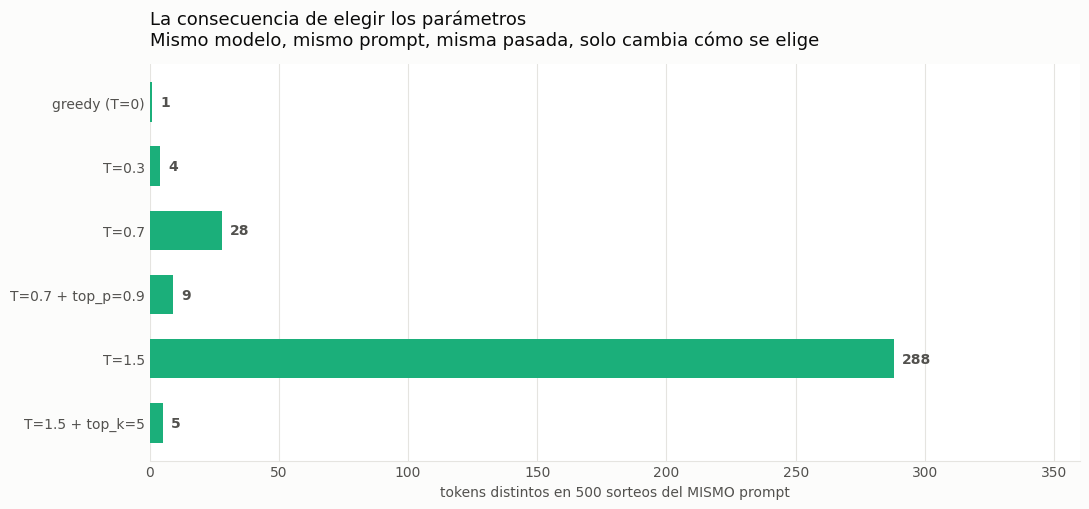

In [ ]:
N = 500
finales = [("greedy (T=0)", logits, True),
           ("T=0.3", temperatura(logits, 0.3), False),
           ("T=0.7", temperatura(logits, 0.7),  False),
           ("T=0.7 + top_p=0.9",  top_p(temperatura(logits, 0.7), 0.9), False),
           ("T=1.5",  temperatura(logits, 1.5),             False),
           ("T=1.5 + top_k=5", top_k(temperatura(logits, 1.5), 5),   False)]

distintos = [len(set(sortear(lg, N, greedy=g).tolist())) for _, lg, g in finales]

fig, ax = nueva_fig("La consecuencia de elegir los parámetros",
                    "Mismo modelo, mismo prompt, misma pasada, solo cambia cómo se elige",
                    eje="x")
barras = ax.barh([n for n, _, _ in finales], distintos, color=CAT[2], height=0.62)
ax.bar_label(barras, padding=6, fontsize=10, color=GRIS, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, max(distintos) * 1.25)
ax.set_xlabel(f"tokens distintos en {N} sorteos del MISMO prompt", color=GRIS, fontsize=10)
plt.tight_layout(); plt.show()

La última fila es la que importa: `T=1.5 + top_k=5` deja exactamente 5 tokens posibles.
El filtro recorta el daño de la temperatura alta. Por eso los parámetros se eligen
en conjunto y no de a uno.

## **h) El orden de aplicación también es un parámetro**

Los mismos valores, aplicados en distinto orden, dejan conjuntos distintos de candidatos.
Hugging Face aplica la temperatura antes de los filtros, otros runtimes no.

In [ ]:
print("Mismos parámetros, distinto orden de aplicación:\n")
print(f"  top_k(20) → top_p(0.9) : {vivos(top_p(top_k(logits, 20), 0.9)):>6} candidatos")
print(f"  top_p(0.9) → top_k(20) : {vivos(top_k(top_p(logits, 0.9), 20)):>6} candidatos")
print(f"  temperatura(1.5) → top_p(0.9) : {vivos(top_p(temperatura(logits, 1.5), 0.9)):>6} candidatos")
print(f"  top_p(0.9) → temperatura(1.5) : {vivos(temperatura(top_p(logits, 0.9), 1.5)):>6} candidatos")

Mismos parámetros, distinto orden de aplicación:

  top_k(20) → top_p(0.9) :     11 candidatos
  top_p(0.9) → top_k(20) :     20 candidatos
  temperatura(1.5) → top_p(0.9) :   3868 candidatos
  top_p(0.9) → temperatura(1.5) :     85 candidatos
